
Dados salvos com sucesso em 'porte_das_empresas.csv'

Gráfico salvo em: 'comparacao.pdf'


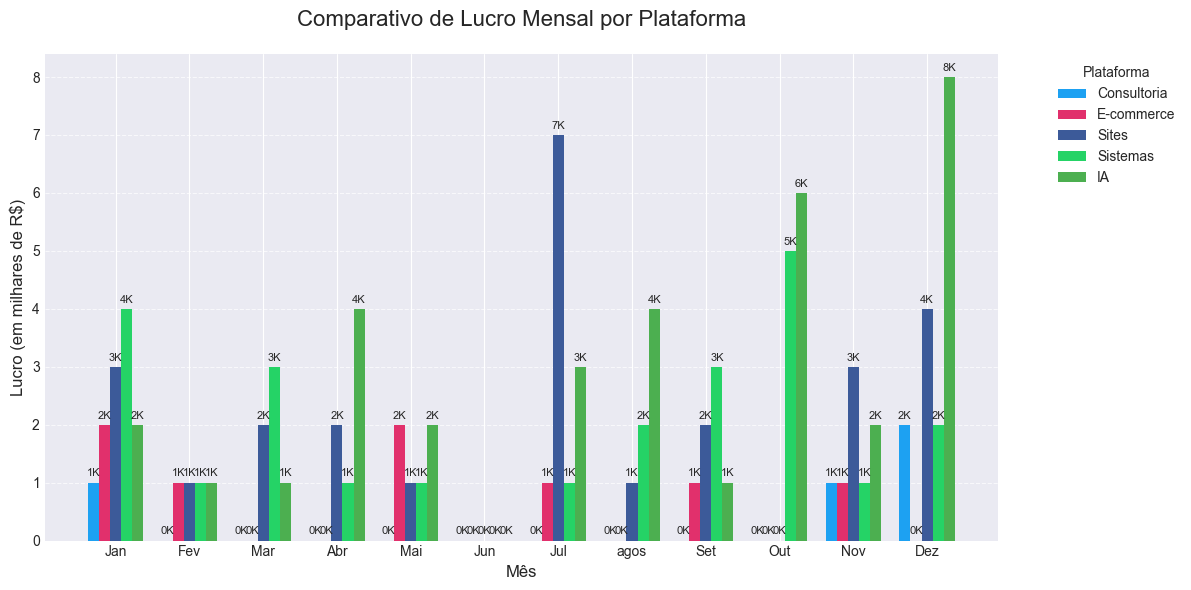


--- Tabela de Dados (Lucro em milhares de R$) ---

     Mês  Consultoria  E-commerce  Sites  Sistemas  IA
0    Jan            1           2      3         4   2
1    Fev            0           1      1         1   1
2    Mar            0           0      2         3   1
3    Abr            0           0      2         1   4
4    Mai            0           2      1         1   2
5    Jun            0           0      0         0   0
6    Jul            0           1      7         1   3
7   agos            0           0      1         2   4
8    Set            0           1      2         3   1
9    Out            0           0      0         5   6
10   Nov            1           1      3         1   2
11   Dez            2           0      4         2   8


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = {
    'Mês': ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun','Jul','agos','Set','Out','Nov','Dez'],
    'Consultoria': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2],
    'E-commerce': [2, 1, 0, 0, 2, 0, 1, 0, 1, 0, 1, 0],
    'Sites': [3, 1, 2, 2, 1, 0, 7, 1, 2, 0, 3, 4],
    'Sistemas': [4, 1, 3, 1, 1, 0, 1, 2, 3, 5, 1, 2],
    'IA': [2, 1, 1, 4, 2, 0, 3, 4, 1, 6, 2, 8]
}

df = pd.DataFrame(data)

nome_arquivo_csv = 'porte_das_empresas.csv'
df.to_csv(nome_arquivo_csv, index=False) 

print(f"\nDados salvos com sucesso em '{nome_arquivo_csv}'")

plataformas = df.columns[1:].tolist()
meses = df['Mês'].tolist()
lucros = df[plataformas].values

x = np.arange(len(meses))  
width = 0.15               
num_plataformas = len(plataformas)

cores = ['#1DA1F2', '#E1306C', '#3c5a99', '#25D366', '#4CAF50']

plt.style.use('seaborn-v0_8-darkgrid') 
fig, ax = plt.subplots(figsize=(12, 6)) 

for i, plataforma in enumerate(plataformas):

    offset = width * i - (width * (num_plataformas - 1) / 2)
    
    rects = ax.bar(x + offset, lucros[:, i], width, label=plataforma, color=cores[i % len(cores)])

    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}K',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=8)
        
ax.set_title('Comparativo de Lucro Mensal por Plataforma', fontsize=16, pad=20)
ax.set_ylabel('Lucro (em milhares de R$)', fontsize=12)
ax.set_xlabel('Mês', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=0)

ax.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

nome_arquivo_pdf = 'comparacao.pdf'
plt.savefig(nome_arquivo_pdf, dpi=300)
print(f"\nGráfico salvo em: '{nome_arquivo_pdf}'")
plt.show()

print("\n--- Tabela de Dados (Lucro em milhares de R$) ---\n")
print(df)